In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('logs/session_20250630-161840/session.csv')
data

,request_arrival_time,response_output_time,preprocess_start_time,inference_start_time,inference_end_time,postprocess_start_time,round_trip_time,server_processing_duration,total_network_latency
0,84295.514879,84296.751598,84295.515019,84295.616409,84296.741914,84296.741914,1.886575,1.236720,0.649855
1,84297.607784,84298.438841,84297.607868,84297.616074,84298.423975,84298.423975,1.438601,0.831058,0.607543
2,84299.813538,84300.364439,84299.813606,84299.815278,84300.355611,84300.355612,1.219707,0.550901,0.668805
3,84301.888694,84302.572127,84301.888826,84301.896096,84302.559565,84302.559565,1.294498,0.683433,0.611066
4,84304.021965,84304.717543,84304.022078,84304.031188,84304.707317,84304.707317,1.308361,0.695579,0.612782
5,84306.159852,84306.887895,84306.159923,84306.166995,84306.874974,84306.874974,1.341669,0.728043,0.613626
6,84308.260939,84308.991075,84308.261454,84308.269072,84308.979367,84308.979368,1.340316,0.730136,0.610181
7,84310.440126,84311.122685,84310.440177,84310.447756,84311.112667,84311.112667,1.397437,0.682559,0.714878


In [3]:
# Calculate the duration of each stage by finding the difference between timestamps
data['server_total_duration'] = data['response_output_time'] - data['request_arrival_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']
data['request_send_duration'] = data['request_arrival_time'] - data['preprocess_start_time']


# This represents network latency plus any other time not captured by the server's timestamps.
data['network_and_other_latency'] = data['round_trip_time'] - data['server_total_duration']
data['response_receive_duration'] = data['network_and_other_latency'] - data['request_send_duration']

# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_total_duration',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    'request_send_duration',
    'response_receive_duration',
    'network_and_other_latency'
]]

# Display the calculated durations for each inference request
print("Calculated Durations for Each Request (in seconds):")
display(durations_df)

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("\nSummary Statistics for Durations (in seconds):")
display(durations_df.describe())

Calculated Durations for Each Request (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,request_send_duration,response_receive_duration,network_and_other_latency
0,1.886575,1.236720,1.125505,0.101390,0.009684,-0.000140,0.649995,0.649855
1,1.438601,0.831058,0.807901,0.008206,0.014866,-0.000085,0.607628,0.607543
2,1.219707,0.550901,0.540334,0.001671,0.008828,-0.000068,0.668873,0.668805
3,1.294498,0.683433,0.663469,0.007270,0.012562,-0.000131,0.611197,0.611066
4,1.308361,0.695579,0.676129,0.009110,0.010226,-0.000114,0.612896,0.612782
5,1.341669,0.728043,0.707979,0.007071,0.012921,-0.000071,0.613698,0.613626
6,1.340316,0.730136,0.710295,0.007619,0.011707,-0.000514,0.610695,0.610181
7,1.397437,0.682559,0.664910,0.007579,0.010018,-0.000051,0.714929,0.714878



Summary Statistics for Durations (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,request_send_duration,response_receive_duration,network_and_other_latency
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,1.403395,0.767303,0.737065,0.018740,0.011351,-0.000147,0.636239,0.636092
std,0.206037,0.204775,0.173413,0.033471,0.002021,0.000152,0.038909,0.038964
min,1.219707,0.550901,0.540334,0.001671,0.008828,-0.000514,0.607628,0.607543
25%,1.304895,0.683214,0.664550,0.007221,0.009935,-0.000134,0.611072,0.610844
50%,1.340993,0.711811,0.692054,0.007599,0.010966,-0.000099,0.613297,0.613204
75%,1.407728,0.755366,0.734696,0.008432,0.012652,-0.000070,0.654714,0.654592
max,1.886575,1.236720,1.125505,0.101390,0.014866,-0.000051,0.714929,0.714878


Summary Statistics for Durations (in seconds):


,round_trip_time,server_processing_duration,total_network_latency,inference_duration,server_preprocess_duration,server_postprocess_duration
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,1.403395,0.767303,0.636092,0.737065,0.018740,0.011351
std,0.206037,0.204775,0.038964,0.173413,0.033471,0.002021
min,1.219707,0.550901,0.607543,0.540334,0.001671,0.008828
25%,1.304895,0.683214,0.610844,0.664550,0.007221,0.009935
50%,1.340993,0.711811,0.613204,0.692054,0.007599,0.010966
75%,1.407728,0.755366,0.654592,0.734696,0.008432,0.012652
max,1.886575,1.236720,0.714878,1.125505,0.101390,0.014866


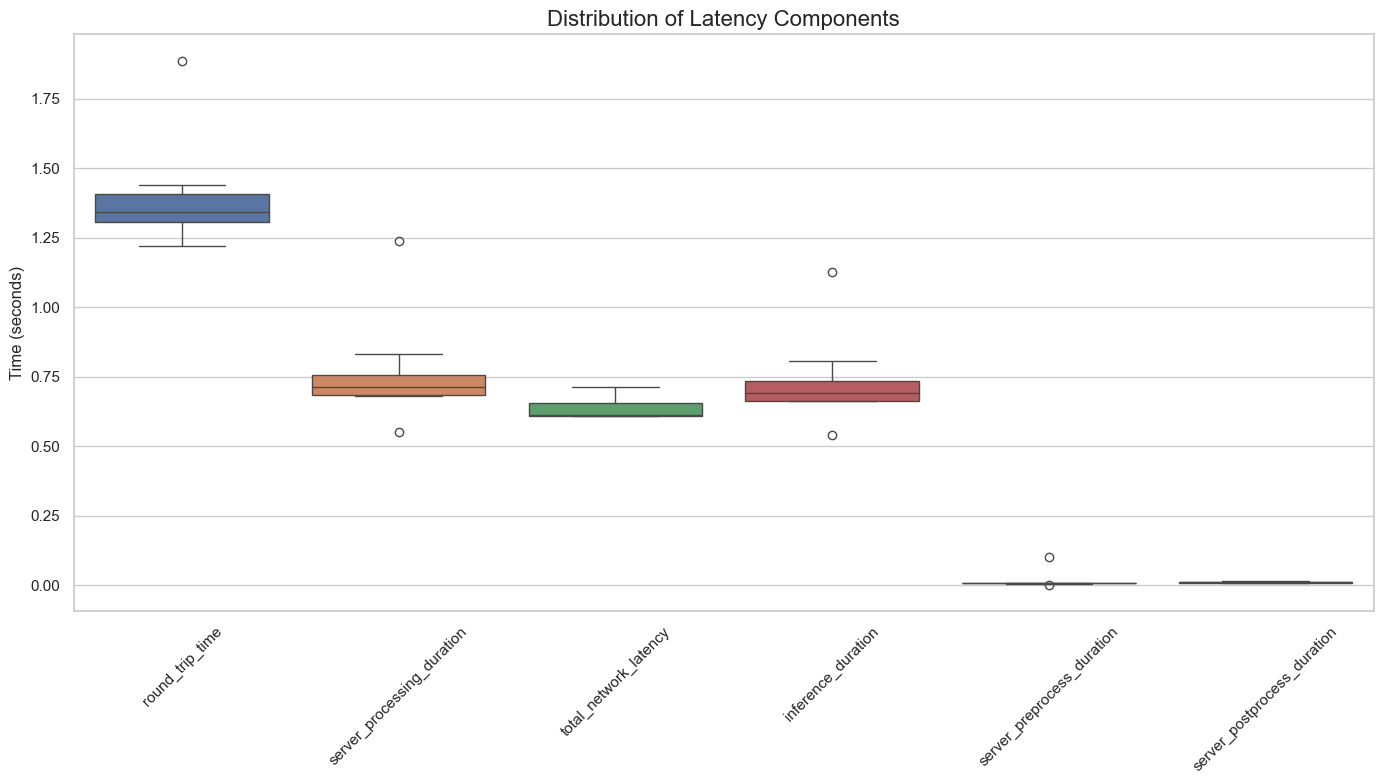

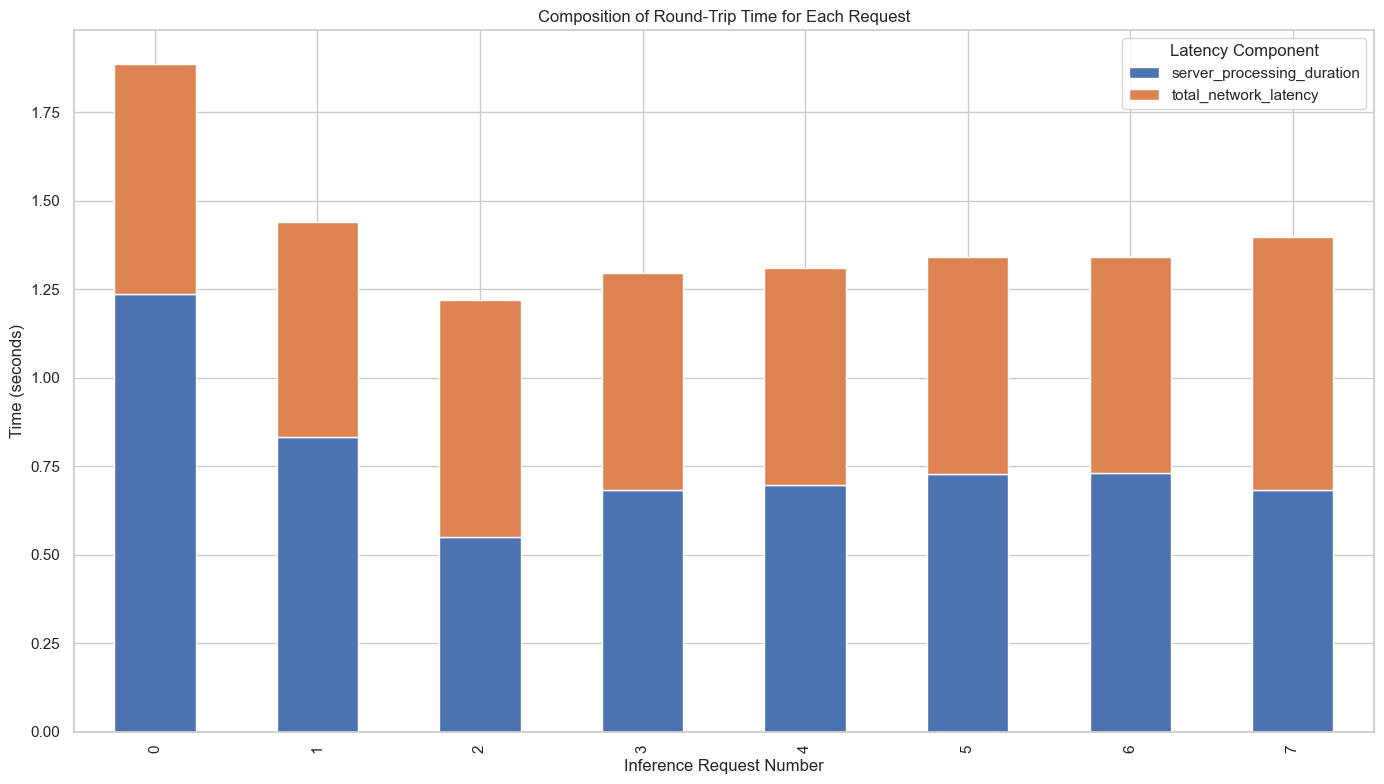

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the duration of each stage by finding the difference between timestamps
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']


# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_processing_duration',
    'total_network_latency',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    
]].copy()

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("Summary Statistics for Durations (in seconds):")
display(durations_df.describe())

# --- Visualization ---

# Set up the plot style
sns.set_theme(style="whitegrid")

# Create a boxplot to see the distribution of each latency component
plt.figure(figsize=(14, 8))
sns.boxplot(data=durations_df)
plt.xticks(rotation=45)
plt.title('Distribution of Latency Components', fontsize=16)
plt.ylabel('Time (seconds)')
plt.tight_layout()
plt.show()

# Create a stacked bar chart to show the composition of the round-trip time
plot_data = durations_df[[
    'server_processing_duration',
    'total_network_latency'
]].copy()
plot_data.reset_index(inplace=True) # Use the request number as the x-axis

plot_data.plot(
    x='index',
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    title='Composition of Round-Trip Time for Each Request'
)
plt.xlabel("Inference Request Number")
plt.ylabel("Time (seconds)")
plt.legend(title='Latency Component')
plt.tight_layout()
plt.show()